In [1]:
import os
import copy
import relbench
import numpy as np
from tqdm import tqdm

import torch
import torch_geometric
import torch_frame

from torch_geometric.seed import seed_everything
import matplotlib.pyplot as plt

import json
import pandas as pd

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
database_name = 'rel-f1'
task_name = 'driver-top3'

### Load Database + Task

In [3]:
from relbench.datasets import get_dataset
from relbench.tasks import get_task

dataset = get_dataset(database_name, download=False)
task = get_task(database_name, task_name, download=False)

### Load Hetero-Graph Data 

alternative, use relbench functionality to build the hetero-graph here. 

In [4]:
data_dir = f"/home/rissakiagapi/rdl-explain-data/relbench_models/{database_name}/"
data = torch.load(os.path.join(data_dir, "data.pt"), weights_only=False)
col_stats_dict = torch.load(os.path.join(data_dir, "col_stats_dict.pt"), weights_only=False)

Note, I needed to modify the node / edge names bellow due to capitalization inconsistency with the relbench dataset + task. 

In [5]:
# change the names of node types from Name to name (lowercase)
# change the names of edge types from (Name1, rel, Name2) to (name1, rel, name2) (lowercase)
from torch_geometric.data import HeteroData

new_data = HeteroData()

for node_type in data.node_types:
    for key, val in data[node_type].items():
        new_data[node_type.lower()][key] = val

for src, rel, dst in data.edge_types:
    for key, val in data[src, rel, dst].items():
        new_data[src.lower(), rel, dst.lower()][key] = val

data = new_data

col_stats_dict = {nt.lower(): stats for nt, stats in col_stats_dict.items()}


### Train relational graph transformer

- First run will precompute neighbor token sequences for all three splits and write HDF5 files to `./relgt-cache/rel-f1/driver-top3/`. Subsequent runs skip this step. The `num_workers=4` controls parallelism for that step.
- `K` and `sample_node_len` must match — both are set to 100. If you change `K`, update `cfg.sample_node_len` too (or just change the `K` variable at the top since `sample_node_len=K`).
- `squeeze()` edge case — `LocalModule.forward` calls `.squeeze()` which will collapse a batch of size 1. This won't affect training (batch_size=64) but if you ever evaluate a single sample, it'll crash. Pre-existing issue in the code, not introduced here.

In [6]:
import sys, copy, math
import numpy as np
from tqdm import tqdm
from torch.nn import BCEWithLogitsLoss, L1Loss
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_
from relbench.base import TaskType

sys.path.insert(0, 'src')
from rdl_explain.model.relgt import RelGT, RelGTConfig, RelGTTokens

# ── Hyperparameters ───────────────────────────────────────────────
K = 100          # neighbor tokens per seed node; must equal sample_node_len below
batch_size = 64
lr = 1e-4
weight_decay = 1e-5
n_epochs = 10
max_steps_per_epoch = 3000
precomputed_dir = "./relgt-cache"

cfg = RelGTConfig(
    local_num_layers=1,
    channels=32, #256, --> updated to smaller
    out_channels=1,    # overridden below for multilabel tasks
    global_dim=32, #128, --> updated to smaller
    heads=4,
    ff_dropout=0.1,
    attn_dropout=0.1,
    conv_type="full",
    num_centroids=4096,
    sample_node_len=K,  # must equal K
)

# ── Datasets ──────────────────────────────────────────────────────
# RelGTTokens precomputes 1- and 2-hop neighbor token sequences and
# caches them in HDF5 under precomputed_dir. On re-runs the cache is
# reused, so precomputation only happens once per (dataset, task, K).
split_datasets = {
    split: RelGTTokens(
        data=data,
        task=task,
        K=K,
        split=split,
        undirected=True,
        precompute=True,
        precomputed_dir=os.path.join(precomputed_dir, database_name, task_name),
        num_workers=4,
    )
    for split in ["train", "val", "test"]
}

loaders = {
    split: DataLoader(
        split_datasets[split],
        batch_size=batch_size,
        shuffle=(split == "train"),
        collate_fn=split_datasets[split].collate,
        num_workers=2,
        persistent_workers=True,
        pin_memory=(device.type == "cuda"),
    )
    for split in ["train", "val", "test"]
}

# ── Task settings ─────────────────────────────────────────────────
clamp_min, clamp_max = None, None
if task.task_type == TaskType.BINARY_CLASSIFICATION:
    loss_fn = BCEWithLogitsLoss()
    tune_metric, higher_is_better = "roc_auc", True
elif task.task_type == TaskType.REGRESSION:
    cfg.out_channels = 1
    loss_fn = L1Loss()
    tune_metric, higher_is_better = "mae", False
    train_table = task.get_table("train")
    clamp_min, clamp_max = np.percentile(
        train_table.df[task.target_col].to_numpy(), [2, 98]
    )
elif task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
    cfg.out_channels = task.num_labels
    loss_fn = BCEWithLogitsLoss()
    tune_metric, higher_is_better = "multilabel_auprc_macro", True
else:
    raise ValueError(f"Unsupported task type: {task.task_type}")

# ── Model ─────────────────────────────────────────────────────────
train_ds = split_datasets["train"]
model = RelGT(
    num_nodes=data.num_nodes,
    max_neighbor_hop=train_ds.max_neighbor_hop,
    node_type_map=train_ds.node_type_to_index,
    col_names_dict={nt: data[nt].tf.col_names_dict for nt in data.node_types},
    col_stats_dict=col_stats_dict,
    **cfg.model_dump(),
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# ── Train / eval ──────────────────────────────────────────────────
def train_epoch(epoch):
    model.train()
    loss_accum, count_accum = 0.0, 0
    for step, batch in enumerate(
        tqdm(loaders["train"], desc=f"Epoch {epoch} [train]"), start=1
    ):
        neighbor_types = batch["neighbor_types"].to(device)
        node_indices   = batch["node_indices"].to(device)
        neighbor_hops  = batch["neighbor_hops"].to(device)
        neighbor_times = batch["neighbor_times"].to(device)
        edge_index     = batch["edge_index"].to(device)
        batch_vec      = batch["batch"].to(device)
        labels         = batch["labels"].to(device)
        grouped_tf_dict = {
            "grouped_tfs":     batch["grouped_tfs"],
            "grouped_indices": batch["grouped_indices"],
            "flat_batch_idx":  batch["flat_batch_idx"],
            "flat_nbr_idx":    batch["flat_nbr_idx"],
        }

        optimizer.zero_grad()
        pred = model(
            neighbor_types, node_indices, neighbor_hops, neighbor_times,
            grouped_tf_dict, edge_index=edge_index, batch=batch_vec,
        )
        pred = pred.view(-1) if pred.size(-1) == 1 else pred
        loss = loss_fn(pred.float(), labels.float())
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        loss_accum += loss.item() * pred.size(0)
        count_accum += pred.size(0)
        if step >= max_steps_per_epoch:
            break

    return loss_accum / count_accum


@torch.no_grad()
def evaluate(split):
    model.eval()
    pred_list, idx_list = [], []
    for batch in tqdm(loaders[split], desc=f"Eval [{split}]"):
        neighbor_types = batch["neighbor_types"].to(device)
        node_indices   = batch["node_indices"].to(device)
        neighbor_hops  = batch["neighbor_hops"].to(device)
        neighbor_times = batch["neighbor_times"].to(device)
        edge_index     = batch["edge_index"].to(device)
        batch_vec      = batch["batch"].to(device)
        grouped_tf_dict = {
            "grouped_tfs":     batch["grouped_tfs"],
            "grouped_indices": batch["grouped_indices"],
            "flat_batch_idx":  batch["flat_batch_idx"],
            "flat_nbr_idx":    batch["flat_nbr_idx"],
        }
        pred = model(
            neighbor_types, node_indices, neighbor_hops, neighbor_times,
            grouped_tf_dict, edge_index=edge_index, batch=batch_vec,
        )
        if clamp_min is not None:
            pred = torch.clamp(pred, clamp_min, clamp_max)
        if task.task_type in [TaskType.BINARY_CLASSIFICATION, TaskType.MULTILABEL_CLASSIFICATION]:
            pred = torch.sigmoid(pred)
        pred = pred.view(-1) if pred.size(-1) == 1 else pred
        pred_list.append(pred.cpu().numpy())
        idx_list.append(batch["global_idx"].cpu().numpy())

    preds = np.concatenate(pred_list)
    idxs  = np.concatenate(idx_list)
    # reorder by global_idx so task.evaluate sees rows in the right order
    ordered = np.empty_like(preds)
    ordered[idxs] = preds
    return ordered


# ── Training loop ─────────────────────────────────────────────────
best_val_metric = -math.inf if higher_is_better else math.inf
best_state = None

for epoch in range(1, n_epochs + 1):
    train_loss  = train_epoch(epoch)
    val_preds   = evaluate("val")
    val_metrics = task.evaluate(val_preds, task.get_table("val"))
    print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f} | val: {val_metrics}")

    improved = (
        (higher_is_better and val_metrics[tune_metric] >= best_val_metric) or
        (not higher_is_better and val_metrics[tune_metric] <= best_val_metric)
    )
    if improved:
        best_val_metric = val_metrics[tune_metric]
        best_state = copy.deepcopy(model.state_dict())

# ── Final evaluation ──────────────────────────────────────────────
model.load_state_dict(best_state)
val_preds    = evaluate("val")
test_preds   = evaluate("test")
val_metrics  = task.evaluate(val_preds, task.get_table("val"))
test_metrics = task.evaluate(test_preds)
print(f"\nBest val:  {val_metrics}")
print(f"Test:      {test_metrics}")


[train] Found existing HDF5 at ./relgt-cache/rel-f1/driver-top3/100/train.h5
[val] Found existing HDF5 at ./relgt-cache/rel-f1/driver-top3/100/val.h5
[test] Found existing HDF5 at ./relgt-cache/rel-f1/driver-top3/100/test.h5
Model parameters: 3,130,454


Eval [val]: 100%|██████████| 10/10 [00:03<00:00,  2.93it/s]


Epoch 01 | train loss: 0.6493 | val: {'average_precision': 0.33616977282256155, 'accuracy': 0.6258503401360545, 'f1': 0.32515337423312884, 'roc_auc': 0.6327784845281397}


Eval [val]: 100%|██████████| 10/10 [00:03<00:00,  3.00it/s]


Epoch 02 | train loss: 0.6239 | val: {'average_precision': 0.4360267929768216, 'accuracy': 0.7465986394557823, 'f1': 0.4581818181818182, 'roc_auc': 0.7342996900252639}


...

Epoch 09 | train loss: 0.4506 | val: {'average_precision': 0.4274224032813833, 'accuracy': 0.7925170068027211, 'f1': 0.45045045045045046, 'roc_auc': 0.6866567522531402}


Eval [val]: 100%|██████████| 10/10 [00:03<00:00,  3.19it/s]


Epoch 10 | train loss: 0.4376 | val: {'average_precision': 0.3785156858794111, 'accuracy': 0.7040816326530612, 'f1': 0.4528301886792453, 'roc_auc': 0.7302682266936624}


Eval [test]: 100%|██████████| 12/12 [00:03<00:00,  3.12it/s]


Best val:  {'average_precision': 0.3810756985826696, 'accuracy': 0.6700680272108843, 'f1': 0.4519774011299435, 'roc_auc': 0.7384386590457079}
Test:      {'average_precision': 0.4082878321312119, 'accuracy': 0.7658402203856749, 'f1': 0.5663265306122449, 'roc_auc': 0.8362118520066889}


### Explain relational graph transformer

#### Generate predictions for explanation task

The explainer learns masks against the model's own predictions (not ground truth).
We generate soft predictions (sigmoid probabilities) and hard predictions for each split.

In [7]:
@torch.no_grad()
def generate_predictions(split):
    """Generate both raw logits and sigmoid predictions for a split."""
    model.eval()
    logit_list, idx_list = [], []
    for batch in tqdm(loaders[split], desc=f"Predictions [{split}]"):
        neighbor_types = batch["neighbor_types"].to(device)
        node_indices   = batch["node_indices"].to(device)
        neighbor_hops  = batch["neighbor_hops"].to(device)
        neighbor_times = batch["neighbor_times"].to(device)
        edge_index     = batch["edge_index"].to(device)
        batch_vec      = batch["batch"].to(device)
        grouped_tf_dict = {
            "grouped_tfs":     batch["grouped_tfs"],
            "grouped_indices": batch["grouped_indices"],
            "flat_batch_idx":  batch["flat_batch_idx"],
            "flat_nbr_idx":    batch["flat_nbr_idx"],
        }
        pred = model(
            neighbor_types, node_indices, neighbor_hops, neighbor_times,
            grouped_tf_dict, edge_index=edge_index, batch=batch_vec,
        )
        pred = pred.view(-1) if pred.size(-1) == 1 else pred
        logit_list.append(pred.cpu().numpy())
        idx_list.append(batch["global_idx"].cpu().numpy())

    logits = np.concatenate(logit_list)
    idxs = np.concatenate(idx_list)
    # reorder by global_idx
    ordered_logits = np.empty_like(logits)
    ordered_logits[idxs] = logits
    return ordered_logits

# Generate predictions for all splits
split_predictions = {}
for split in ["train", "val", "test"]:
    logits = generate_predictions(split)
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    hard = (probs >= 0.5).astype(float)
    split_predictions[split] = {
        "output": logits,
        "processed_output": probs,
        "predictions": hard,
    }
    print(f"{split}: {len(logits)} predictions, positive rate = {hard.mean():.3f}")

Predictions [train]: 100%|██████████| 22/22 [00:08<00:00,  2.59it/s]


train: 1353 predictions, positive rate = 0.285


Predictions [val]: 100%|██████████| 10/10 [00:02<00:00,  3.40it/s]


val: 588 predictions, positive rate = 0.386


Predictions [test]: 100%|██████████| 12/12 [00:03<00:00,  3.30it/s]

test: 726 predictions, positive rate = 0.366


#### Create explanation task

Build an explanation task from the prediction task by injecting model predictions
as the target column. The explainer will learn masks that preserve these predictions.

In [9]:
explanation_target_type = 'soft'  # 'soft' (sigmoid probs) or 'hard' (0/1 labels)

explanation_task = copy.deepcopy(task)

for split in ["train", "val", "test"]:
    table = explanation_task.get_table(split)
    preds = split_predictions[split]
    table.df["output"] = preds["output"]
    table.df["processed_output"] = preds["processed_output"]
    table.df["predictions"] = preds["predictions"]
    # Set the table as an attribute so the explainer's _initialize_task_tables can find it
    setattr(explanation_task, f"{split}_table", table)

# Set the target column to soft or hard predictions
explanation_task.explanation_target_type = explanation_target_type
if explanation_target_type == 'soft':
    explanation_task.target_col = 'processed_output'
else:
    explanation_task.target_col = 'predictions'

# Fix entity_table capitalization to match data.pt node types
entity_table_lower = explanation_task.entity_table.lower()
for key in data.node_types:
    if key.lower() == entity_table_lower:
        explanation_task.entity_table = key
        break

print(f"Entity table: {explanation_task.entity_table}")
print(f"Target column: {explanation_task.target_col}")
print(f"Train table shape: {explanation_task.train_table.df.shape}")
display(explanation_task.train_table.df.head())

Entity table: drivers
Target column: processed_output
Train table shape: (1353, 6)


,date,driverId,qualifying,output,processed_output,predictions
0,2004-08-04,12,0,-0.278888,0.430726,0.0
1,2004-08-04,20,0,-0.206988,0.448437,0.0
2,2004-07-05,10,0,-0.245802,0.438857,0.0
3,2004-07-05,47,0,-1.222416,0.227512,0.0
4,2004-06-05,31,0,-0.948205,0.279246,0.0


#### Initialize the RelGT Explainer

In [10]:
from rdl_explain.explain.config import ExplainerConfig
from rdl_explain.explain.relgt_explainer import RelGTExplainer

# gnn_layers is unused by RelGTExplainer but required by ExplainerConfig
explainer_config = ExplainerConfig(device=device, gnn_layers=1, inference_batch_size=batch_size)

explainer = RelGTExplainer(
    config=explainer_config,
    model=model,
    data=data,
    task=explanation_task,
    K=K,
    precomputed_dir=os.path.join(precomputed_dir, database_name, task_name),
    num_dataset_workers=4,
    num_loader_workers=2,
)
print("RelGTExplainer initialized.")

[train] Found existing HDF5 at ./relgt-cache/rel-f1/driver-top3/100/train.h5
[val] Found existing HDF5 at ./relgt-cache/rel-f1/driver-top3/100/val.h5
[test] Found existing HDF5 at ./relgt-cache/rel-f1/driver-top3/100/test.h5
RelGTExplainer initialized.


#### Learn Column Masks

In [11]:
mask_type = 'column'
eps = 0.001           # L1 regularization weight
lr = 0.05             # learning rate for mask parameters
n_epochs = 250         # number of mask learning epochs
elimination_strategy = 'permutation_joint'  # how to eliminate masked features

print(f"Learning {mask_type} masks (eps={eps}, lr={lr}, epochs={n_epochs}, elimination={elimination_strategy})")

global_mask, global_mask_vals, global_metrics = explainer.learn_masks(
    eps=eps,
    explanation_type=mask_type,
    elimination_strategy=elimination_strategy,
    n_epochs=n_epochs,
    lr=lr,
)

Learning column masks (eps=0.001, lr=0.05, epochs=250, elimination=permutation_joint)


Epoch 0/250: Loss 0.6814891186342075 - Task Loss 0.6364951207667593 - Regularization 44.99399554244871 - Time-per-epoch 7.72s
Epoch 25/250: Loss 0.6471162852426607 - Task Loss 0.6394548896906124 - Regularization 7.661395191353335 - Time-per-epoch 7.96s
Epoch 50/250: Loss 0.6470129357932274 - Task Loss 0.6394359865234667 - Regularization 7.576948887669238 - Time-per-epoch 6.84s
Epoch 75/250: Loss 0.6469324630453852 - Task Loss 0.6395266728754451 - Regularization 7.4057898190139575 - Time-per-epoch 6.97s
Epoch 100/250: Loss 0.6471895747623444 - Task Loss 0.6392605639272957 - Regularization 7.929010344714653 - Time-per-epoch 6.76s
Epoch 125/250: Loss 0.6470188796758147 - Task Loss 0.6395137800511302 - Regularization 7.505099266260884 - Time-per-epoch 6.73s
Mask learning stopped early at epoch 135 due to convergence.
Mask learning completed in 960.46 seconds.


#### Visualize learned column masks

Explanation elements above threshold 0.1: 11 / 45


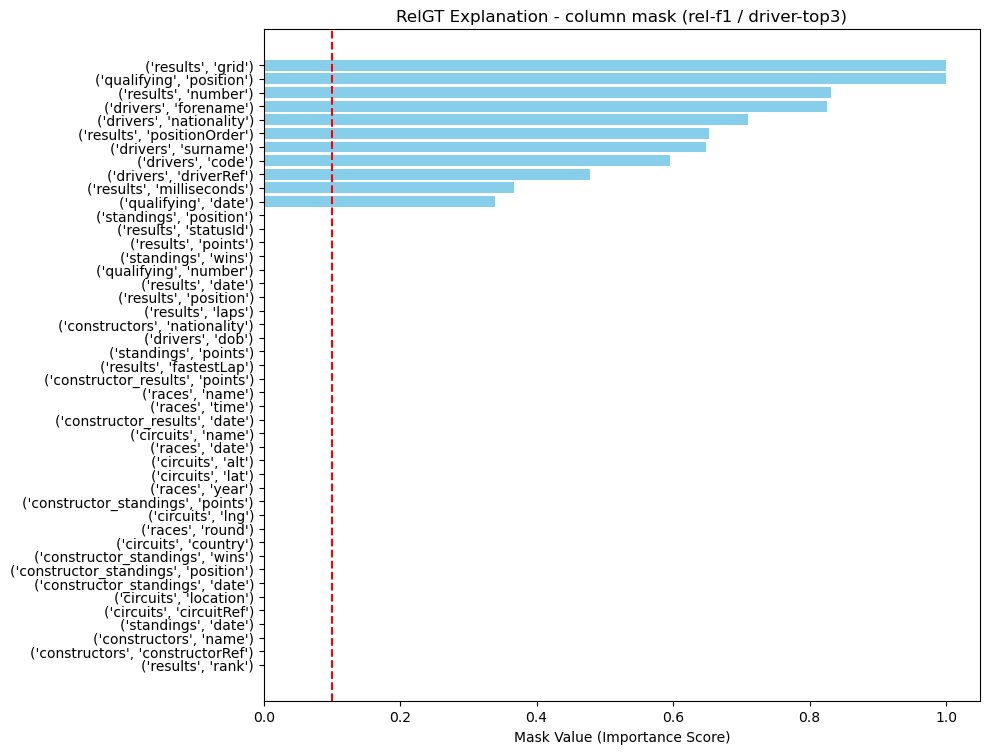

In [12]:
# Prepare data for plotting
explanation_elements = []
importance_scores = []
for explanation_element, mask_value in global_mask.items():
    explanation_elements.append(f'{explanation_element}')
    importance_scores.append(torch.sigmoid(mask_value).item())

importance_df = pd.DataFrame({
    'Explanation Element': explanation_elements,
    'Importance Score': importance_scores,
})
importance_df = importance_df.sort_values(by='Importance Score', ascending=False)
threshold = 0.1

# Plot
plt.figure(figsize=(10, max(3, 0.17 * len(importance_df))))
plt.barh(importance_df['Explanation Element'], importance_df['Importance Score'], color='skyblue')
plt.xlabel('Mask Value (Importance Score)')
plt.title(f'RelGT Explanation - {mask_type} mask ({database_name} / {task_name})')
plt.gca().invert_yaxis()
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.tight_layout()

num_important = (importance_df['Importance Score'] > threshold).sum()
print(f'Explanation elements above threshold {threshold}: {num_important} / {len(importance_df)}')

os.makedirs(f'./figures/{database_name}_{task_name}', exist_ok=True)
plt.savefig(f'./figures/{database_name}_{task_name}/relgt_explanation_{mask_type}_mask_eps_{eps}.png')
plt.show()

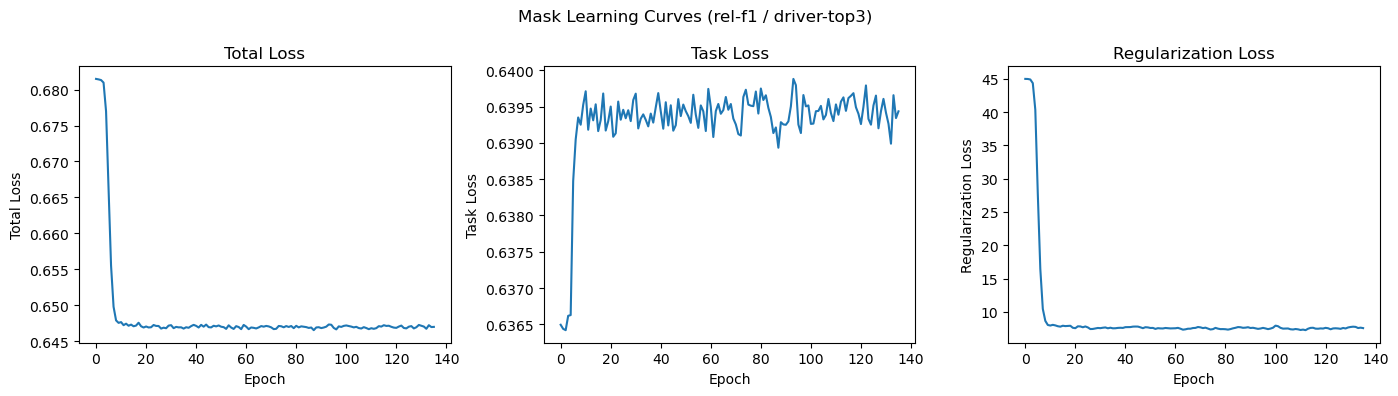

In [13]:
# Plot mask learning loss curve
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (key, label) in zip(axes, [('loss', 'Total Loss'), ('task_loss', 'Task Loss'), ('reg_loss', 'Regularization Loss')]):
    ax.plot(global_metrics[key])
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.set_title(label)
fig.suptitle(f'Mask Learning Curves ({database_name} / {task_name})')
plt.tight_layout()
plt.show()